# Deep Learning for Neuroimaging Analysis: MLP for Age-Related Classification based on Functional Connectivity

In this notebook, we applied a multi-layer perceptron (MLP) to a publicly available resting-state fMRI dataset (the nilearn development resting-state fMRI dataset `nilearn.datasets.fetch_development_fmri`, n = 60 subjects (47 children and 13 adults), 4-D functional NIfTI, confounds (auto-downloaded via nilearn)) to classify **children vs adults**. More specifically, we extracted region-to-region correlation matrices (functional connectivity) and fed them into an MLP to classify children vs. adults, that is, to discriminate children from adults based on resting-state functional connectivity. We implemented an MLP with batch normalization, dropout, and two hidden layers.

<br>

In [1]:
#!pip install nilearn nibabel torch torchvision scikit-learn matplotlib seaborn tqdm

In [9]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

import nibabel as nib
import nilearn
from nilearn import datasets, plotting, image, connectome
from nilearn.maskers import NiftiLabelsMasker, NiftiMasker

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as tv_models

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  |  nilearn {nilearn.__version__}  |  device: {DEVICE}')

PyTorch 2.10.0+cpu  |  nilearn 0.13.0  |  device: cpu


---
## 1. The Development fMRI Dataset

Resting-state fMRI captures spontaneous fluctuations in the BOLD signal. Each subject contributes a 4-D NIfTI volume (x, y, z, time) plus a table of nuisance confounds.

In [3]:
#Fetch resting-state fMRI: Development dataset
#~30 children + ~30 adults, TR=2s, ~168 volumes each

dev_data = datasets.fetch_development_fmri(n_subjects = 60, reduce_confounds = True)

print('Functional images:', len(dev_data.func))
print('Confounds shape example:',
      np.load(dev_data.confounds[0]).shape if dev_data.confounds[0].endswith('.npy')
      else 'CSV-based confounds')

[fetch_development_fmri] Dataset found in C:\Users\heito\nilearn_data\development_fmri

[fetch_development_fmri] Dataset found in C:\Users\heito\nilearn_data\development_fmri\development_fmri

[fetch_development_fmri] Dataset found in C:\Users\heito\nilearn_data\development_fmri\development_fmri

Functional images: 60
Confounds shape example: CSV-based confounds


---
## 2. Temporal Preprocessing and Parcellation

Temporal preprocessing: Detrending, band-pass filtering to the resting-state band, and confound regression. An atlas (Schaefer-100) then reduces the voxel time-series to one time-series per region. Also, the atlas is cortical-only, so the resulting connectomes contain no subcortical or cerebellar nodes.

In [4]:
#Extract time-series with a Schaefer-100 atlas:

atlas = datasets.fetch_atlas_schaefer_2018(n_rois = 100, yeo_networks = 7, resolution_mm = 2)

roi_masker = NiftiLabelsMasker(
    labels_img = atlas.maps,
    standardize = True,
    detrend = True,
    low_pass = 0.1,
    high_pass = 0.01,
    t_r = 2.0,
    memory = 'nilearn_cache',
    verbose = 0)

timeseries_list = []
for func, conf in zip(dev_data.func, dev_data.confounds):
    ts = roi_masker.fit_transform(func, confounds = conf)
    timeseries_list.append(ts)

print(f'Time-series per subject: {timeseries_list[0].shape}  (time-points × ROIs)')

[fetch_atlas_schaefer_2018] Dataset found in C:\Users\heito\nilearn_data\schaefer_2018

Time-series per subject: (168, 100)  (time-points × ROIs)


---
## 3. Functional Connectivity (Correlation)

Region-to-region connectivity is summarised as a matrix per subject and vectorised into a feature vector for classification. Connectivity features: tangent-space parameterisation.

In [5]:
#Computing tangent-space connectivity matrices:

conn_measure = connectome.ConnectivityMeasure(kind = 'tangent', vectorize = True, discard_diagonal = True)
X_conn = conn_measure.fit_transform(timeseries_list)   #[n_subjects × n_features]

#Labels: 0 = child, 1 = adult:
y_dev = (np.array(dev_data.phenotypic['Child_Adult']) == 'adult').astype(int)
print(f'Connectivity feature matrix: {X_conn.shape}')
print(f'Children: {(y_dev==0).sum()}  |  Adults: {(y_dev==1).sum()}')

Connectivity feature matrix: (60, 4950)
Children: 47  |  Adults: 13


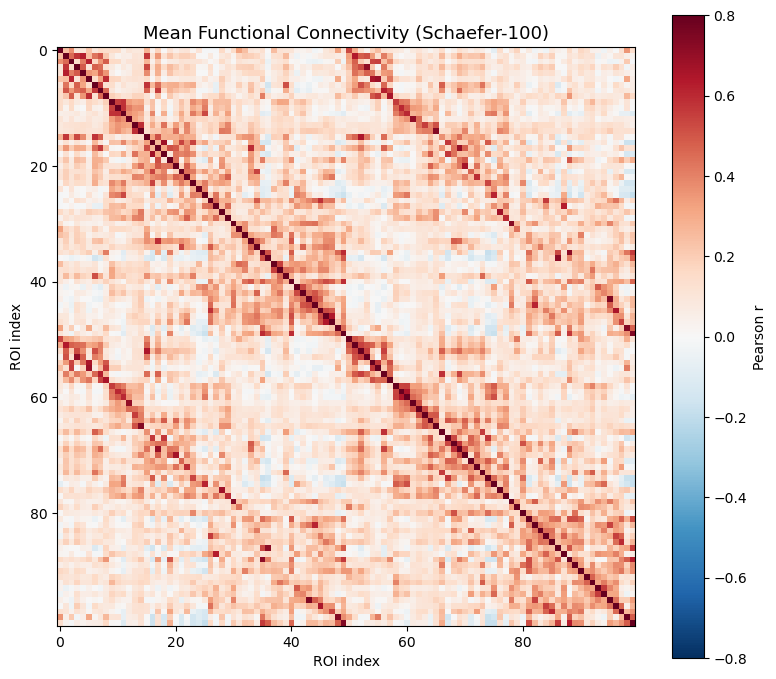

In [6]:
#Visualising mean connectivity matrix (correlation):

conn_full = connectome.ConnectivityMeasure(kind = 'correlation')
matrices  = conn_full.fit_transform(timeseries_list)
mean_mat  = matrices.mean(axis = 0)

fig, ax = plt.subplots(figsize = (8, 7))
im = ax.imshow(mean_mat, vmin = -0.8, vmax = 0.8, cmap = 'RdBu_r', interpolation = 'nearest')
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_title('Mean Functional Connectivity (Schaefer-100)', fontsize=13)
ax.set_xlabel('ROI index')
ax.set_ylabel('ROI index')
plt.tight_layout()
plt.show()

---
## 4. MLP Classifier and Results

Now we implement a shallow multi-layer perceptron on the vectorised connectivity features to classify **children vs adults**.

In [10]:
#MLP classifier on connectivity features:

class ConnMLP(nn.Module):
    """Shallow MLP for functional-connectivity classification."""
    def __init__(self, in_features: int, hidden: int = 256, dropout: float = 0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),)

    def forward(self, x):
        return self.net(x).squeeze(1)

class ConnDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype = torch.float32)
        self.y = torch.tensor(y, dtype = torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [11]:
def fit_predict_subjects(train_idx, test_idx, timeseries, y,
                         epochs = 80, lr = 1e-3, batch_size = 16, seed = 0):

    torch.manual_seed(seed)

    #features: fit the tangent projection on train subjects only.
    conn = connectome.ConnectivityMeasure(kind='tangent', vectorize=True,
                                          discard_diagonal=True)
    X_train = conn.fit_transform([timeseries[i] for i in train_idx])
    X_test  = conn.transform([timeseries[i] for i in test_idx])

    scaler  = StandardScaler().fit(X_train)
    X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)
    y_train = y[train_idx]

    train_dl = DataLoader(ConnDataset(X_train, y_train), batch_size = batch_size,
                          shuffle=True, drop_last=True)

    #--- model ---
    model   = ConnMLP(in_features=X_train.shape[1]).to(DEVICE)
    pos_weight = torch.tensor([(y_train == 0).sum() / max((y_train == 1).sum(), 1)],
                              dtype = torch.float32, device=DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt     = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched   = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    for _ in range(epochs):
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            opt.step()
        sched.step()

    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X_test, dtype=torch.float32, device = DEVICE))
        return torch.sigmoid(logits).cpu().numpy()


baseline = max(np.mean(y_dev), 1 - np.mean(y_dev))
print(f'Children: {(y_dev == 0).sum()}  |  Adults: {(y_dev == 1).sum()}')
print(f'Majority-class baseline: {baseline:.3f}')

Children: 47  |  Adults: 13
Majority-class baseline: 0.783


In [12]:
#Single test set (stratified, subject level):

train_idx, test_idx = train_test_split(np.arange(len(y_dev)), test_size = 0.2,
                                       stratify=y_dev, random_state = 8561)
y_test = y_dev[test_idx]
print(f'Train: {len(train_idx)} subjects  |  '
      f'Test: {len(test_idx)} subjects ({(y_test == 1).sum()} adults)')

probs_test = fit_predict_subjects(train_idx, test_idx, timeseries_list, y_dev)
preds_test = (probs_test > 0.5).astype(int)

print(f'\nTest accuracy: {accuracy_score(y_test, preds_test):.3f}')
print(f'Test balanced accuracy: {balanced_accuracy_score(y_test, preds_test):.3f}')
print(f'Test ROC-AUC: {roc_auc_score(y_test, probs_test):.3f}')
print(f'Majority baseline: {baseline:.3f}')

Train: 48 subjects  |  Test: 12 subjects (3 adults)

Test accuracy          : 1.000
Test balanced accuracy : 1.000
Test ROC-AUC           : 1.000
Majority baseline      : 0.783


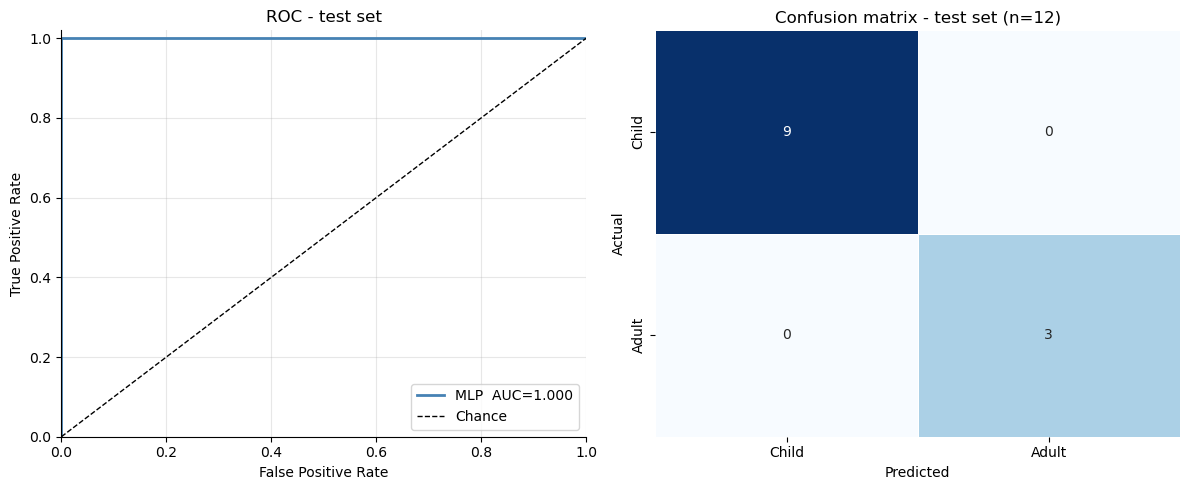

In [18]:
#Test-set ROC curve and confusion matrix:

class_names = ['Child', 'Adult']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_test, probs_test)
axes[0].plot(fpr, tpr, lw=2, color='steelblue', label=f'MLP  AUC={auc(fpr, tpr):.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC - test set'); axes[0].legend(loc='lower right')
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1.02); axes[0].grid(alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)

cm_test = confusion_matrix(y_test, preds_test)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=class_names, yticklabels = class_names,
            linewidths=0.5, cbar=False)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].set_title(f'Confusion matrix - test set (n={len(y_test)})')

plt.tight_layout()
plt.show()

In [14]:
#Cross-validated out-of-fold predictions (all 60 subjects):

skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 8561)
oof_probs = np.zeros(len(y_dev))

for fold, (tr, te) in enumerate(skf.split(np.zeros(len(y_dev)), y_dev), start=1):
    oof_probs[te] = fit_predict_subjects(tr, te, timeseries_list, y_dev, seed=fold)
    print(f'  fold {fold}/5 done  ({len(te)} test subjects, '
          f'{(y_dev[te] == 1).sum()} adults)')

oof_preds = (oof_probs > 0.5).astype(int)

print(f'\nOut-of-fold accuracy: {accuracy_score(y_dev, oof_preds):.3f}')
print(f'Out-of-fold balanced accuracy: {balanced_accuracy_score(y_dev, oof_preds):.3f}')
print(f'Out-of-fold ROC-AUC: {roc_auc_score(y_dev, oof_probs):.3f}')
print(f'Majority baseline: {baseline:.3f}')

  fold 1/5 done  (12 test subjects, 3 adults)
  fold 2/5 done  (12 test subjects, 3 adults)
  fold 3/5 done  (12 test subjects, 3 adults)
  fold 4/5 done  (12 test subjects, 2 adults)
  fold 5/5 done  (12 test subjects, 2 adults)

Out-of-fold accuracy          : 0.983
Out-of-fold balanced accuracy : 0.962
Out-of-fold ROC-AUC           : 0.959
Majority baseline             : 0.783


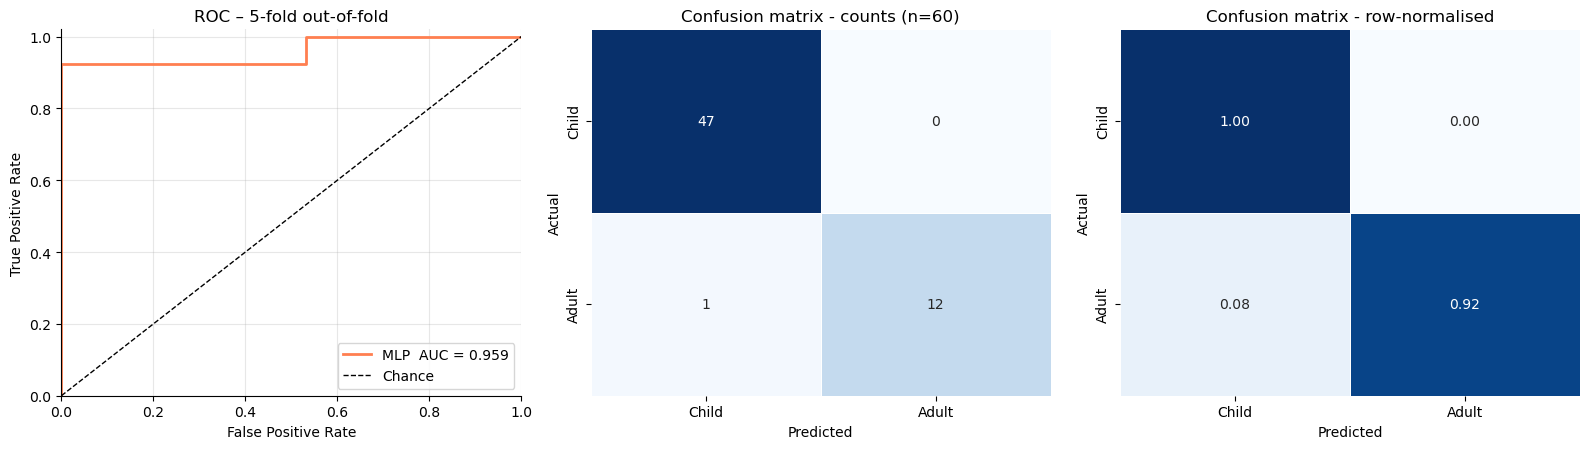

In [19]:
#Cross-validated ROC curve and confusion matrix:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

fpr, tpr, _ = roc_curve(y_dev, oof_probs)
axes[0].plot(fpr, tpr, lw=2, color = 'coral', label = f'MLP  AUC = {auc(fpr, tpr):.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC \u2013 5-fold out-of-fold'); axes[0].legend(loc='lower right')
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1.02); axes[0].grid(alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)

cm_oof = confusion_matrix(y_dev, oof_preds)
sns.heatmap(cm_oof, annot = True, fmt = 'd', cmap = 'Blues', ax = axes[1],
            xticklabels = class_names, yticklabels = class_names,
            linewidths = 0.5, cbar=False)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion matrix - counts (n=60)')

cm_norm = confusion_matrix(y_dev, oof_preds, normalize = 'true')
sns.heatmap(cm_norm, annot=True, fmt = '.2f', cmap = 'Blues', ax = axes[2],
            xticklabels=class_names, yticklabels = class_names,
            linewidths = 0.5, cbar=False, vmin = 0, vmax = 1)
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')
axes[2].set_title('Confusion matrix - row-normalised')

plt.tight_layout()
plt.show()

In [ ]:
#Note: 13 adults is a small sample. Even with cross-validation, per-class recall for adults rests on 13 subjects, 
#so its confidence interval is wide; thus let's treat these results as a demonstration of the evaluation protocol, 
#not as evidence about developmental connectivity.